# Máquinas Térmicas - Lección 10
## Máquinas hidráulicas de desplazamiento positivo (Compresores y turbinas reciprocantes)

**Autor:** Camilo Bayona
**Fecha:** 02/09/2025

*Todo lo que sigue es una aplicación de la **Lección 1** (procesos politrópicos): un compresor no es más que una máquina que recorre $pV^n=\text{cte}$ una y otra vez, y cada tecnología de esta lección — volumen residual, válvulas, multietapas, Roots, Lysholm — es una estrategia distinta para lidiar con las consecuencias de esa ecuación.*

### Objetivos de aprendizaje
1. Interpretar el diagrama $P$-$V$ de un compresor de desplazamiento positivo (ideal, con volumen residual, real con válvulas) y calcular el trabajo de compresión a partir de la teoría politrópica de la Lección 1.
2. Definir y aplicar la eficiencia volumétrica $\eta_v$, evaluando el efecto del volumen residual, la relación de presiones y las pérdidas de válvula.
3. Diseñar esquemas de compresión multietapa con enfriamiento intermedio (presión intermedia óptima) y evaluar la eficiencia isentrópica del compresor con propiedades reales del aire.
4. Comparar compresores reciprocantes (con válvulas) frente a rotativos de desplazamiento positivo sin válvulas (Roots, Lysholm), identificando ventajas, limitaciones y campos de aplicación.

In [ ]:
# Instalación solo en Google Colab; en el entorno local del curso es un no-op
import sys
if "google.colab" in sys.modules:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "matplotlib", "ipywidgets", "numpy", "scipy", "CoolProp"], check=True)

In [ ]:
# === Setup =================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch, Wedge, Polygon, FancyBboxPatch
from scipy.optimize import brentq, minimize_scalar
from ipywidgets import (interact, interactive_output, FloatSlider, IntSlider,
                        Dropdown, Checkbox, Play, HBox, VBox, jslink)
from IPython.display import display
from CoolProp.CoolProp import PropsSI

Rgas = 287.0  # J/(kg·K), aire

# Paleta del proyecto (misma que Lecciones 7-9; remapeada al lenguaje de compresores)
COL = {"aire": "#2a78d6", "abierta": "#1baf7a", "cerrada": "#8a8a86", "perdida": "#e34948",
       "etapa2": "#eb6834", "agua": "#1baf7a", "isentropico": "#4a3aa7",
       "metal": "#c3c2b7", "tinta": "#3a3a38"}

print("Setup OK")

Setup OK


## 1. Introducción

El elemento de impartición de energía no tiene que tener necesariamente movimiento
alternativo (émbolo), sino que puede tener movimiento rotativo (rotor).
Sin embargo, en las máquinas de desplazamiento positivo tanto alternativas como rotativas, siempre hay una cámara que aumenta de volumen
(succión en una bomba) o disminuye de volumen (impulsión). Por eso se llaman también máquinas volumétricas.

### 1.0 Marco: todo es un proceso politrópico

De la Lección 1, cualquier compresión o expansión cuasiestática de un gas ideal sigue $PV^n=\text{cte}$, con trabajo de entrada

$$w_{in} = \frac{RT_1}{n-1}\left[\left(\frac{P_2}{P_1}\right)^{(n-1)/n} - 1\right]$$

y ese único parámetro $n$ ya anuncia el hilo conductor de toda la lección:

| $n$ | proceso | consecuencia en el compresor |
|---|---|---|
| $n=1$ | isotérmico | **mínimo** trabajo teórico de compresión — el límite que persigue el interenfriamiento (§5) |
| $1<n<k$ | politrópico real | hay rechazo parcial de calor por las paredes del cilindro — el caso real de este cuaderno (§1-4) |
| $n=k=c_p/c_v$ | isentrópico (adiabático reversible) | **máximo** trabajo de compresión — la referencia ideal para $\eta_c$ (§6) |

Como ya se explicó en la Lección 1 (§2.4): *"por eso los compresores se refrigeran (interenfriamiento), acercándose al límite isotérmico"* — todo el diseño de un compresor es, en el fondo, una negociación entre estos tres valores de $n$.

### 1.1. Diagrama $P$ - $V$

En el diagrama de presión contra volumen la línea $d$-$a$ representa la carrera de succión. La masa en el cilindro aumenta desde cero en $d$ hasta la cantidad requerida para llenar el cilindro en $a$.

En el caso ideal, la temperatura se mantiene constante en $T_1$ durante este proceso y no hay intercambio de calor con el entorno.

La succión comienza cuando la diferencia de presión a través de la válvula es suficiente para abrirla.

La línea $abc$ representa la carrera de compresión y entrega.

A medida que el pistón comienza su carrera de retorno, la presión en el cilindro aumenta y cierra la válvula de entrada.

El aumento de presión continúa con el pistón en retorno, como se muestra en la línea $ab$, hasta que se alcanza la presión en la que se abre la válvula de entrega (un valor determinado por la válvula y la presión en el receptor).

La entrega tiene lugar según lo muestra la línea $bc$, que es un proceso a temperatura constante $T_2$, presión constante $p_2$, intercambio de calor nulo y masa decreciente.

Al final de esta carrera, se repite el ciclo. El valor de la temperatura de entrega $T_2$ depende de la ley de compresión entre $a$ y $b$, que a su vez depende del intercambio de calor con el entorno durante este proceso. Puede suponerse que la forma general de compresión es la politrópica reversible con lo que:

$$pV^n = \text{cte}$$

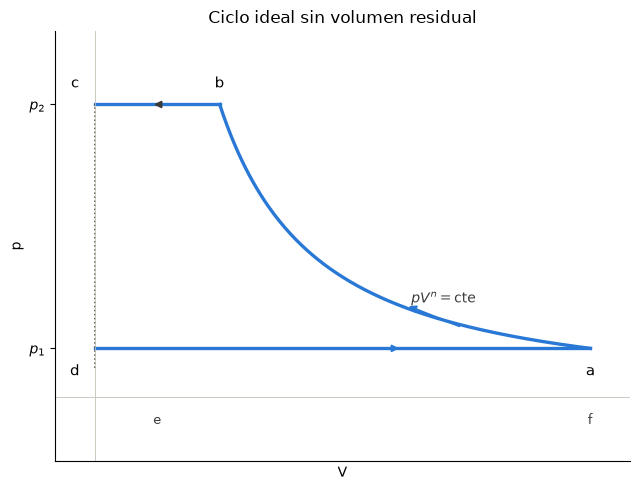

In [ ]:
# Diagrama P-V ideal (Eastop & McConkey) — función reutilizable en §1-3
def pv_diagram_ideal(ax, p1=1.0, p2=6.0, V1=10.0, n=1.3, Vc=0.0, sombrear_ind=False):
    # p1,p2 en bar; V1,Vc en L (unidades de graficación). Vc=0 -> ciclo simple d-a-b-c (sin holgura)
    V2 = V1*(p1/p2)**(1/n)                       # b: fin de compresión
    Vd = Vc*(p2/p1)**(1/n) if Vc > 0 else 0.0     # d: fin de reexpansión (si hay holgura)
    Vcomp = np.linspace(V2, V1, 200)
    Pcomp = p1*(V1/Vcomp)**n
    ax.plot(Vcomp, Pcomp, color=COL["aire"], lw=2.4)
    ax.annotate("", xy=(Vcomp[100], Pcomp[100]*1.03), xytext=(Vcomp[130], Pcomp[130]*0.97),
                arrowprops=dict(arrowstyle="-|>", color=COL["aire"], lw=1.4))
    ax.text((V1+V2)/2*1.02, (p1+p2)/2*0.55, "$pV^n=\\mathrm{cte}$", fontsize=10, color=COL["tinta"])
    ax.plot([V2, Vc if Vc > 0 else 0], [p2, p2], color=COL["aire"], lw=2.4)      # entrega b-c
    ax.annotate("", xy=((V2+(Vc if Vc>0 else 0))*0.45, p2), xytext=((V2+(Vc if Vc>0 else 0))*0.55, p2),
                arrowprops=dict(arrowstyle="-|>", color=COL["tinta"], lw=1.4))
    ax.plot([Vd if Vc > 0 else 0, V1], [p1, p1], color=COL["aire"], lw=2.4)      # induccion d-a
    ax.annotate("", xy=(V1*0.62, p1), xytext=(V1*0.5, p1),
                arrowprops=dict(arrowstyle="-|>", color=COL["aire"], lw=1.4))
    if Vc > 0:
        Vexp = np.linspace(Vc, Vd, 100)
        Pexp = p2*(Vc/Vexp)**n
        ax.plot(Vexp, Pexp, color=COL["aire"], lw=2.4)                           # reexpansion c-d
        ax.plot([Vc, Vc], [p1*0.5, p2], color=COL["tinta"], lw=1.1, ls=":")
        for Vx, lbl, dy in [(Vc, "c", 0.35), (Vd, "d", -0.55)]:
            ax.text(Vx, (p2 if lbl == "c" else p1) + dy, lbl, fontsize=11, ha="center")
        ax.text(V2, p2 + 0.35, "b", fontsize=11, ha="center")
        ax.text(V1, p1 - 0.55, "a", fontsize=11, ha="center")
        ax.annotate("", xy=(Vc, -0.85*p1), xytext=(0, -0.85*p1),
                    arrowprops=dict(arrowstyle="<->", color=COL["tinta"], lw=1))
        ax.text(Vc/2, -1.15*p1, "$V_c$", ha="center", fontsize=9, color=COL["tinta"])
        ax.annotate("", xy=(V1, -0.85*p1), xytext=(Vc, -0.85*p1),
                    arrowprops=dict(arrowstyle="<->", color=COL["tinta"], lw=1))
        ax.text((Vc+V1)/2, -1.15*p1, "$V_s$", ha="center", fontsize=9, color=COL["tinta"])
        if sombrear_ind:
            ax.fill_betweenx([p1*0.94, p1*1.0], Vd, V1, color=COL["perdida"], alpha=0.22)
            ax.text((Vd+V1)/2, p1*0.75, "$V_{ind}$", ha="center", fontsize=9, color=COL["perdida"])
        ax.set_xlim(-V1*0.08, V1*1.08); ax.set_ylim(-p1*1.55, p2*1.25)
    else:
        ax.plot([0, 0], [p1*0.6, p2], color=COL["tinta"], lw=1.1, ls=":")
        for Vx, Px, lbl, dx, dy in [(0, p2, "c", -0.4, 0.35), (V2, p2, "b", 0, 0.35),
                                    (V1, p1, "a", 0, -0.55), (0, p1, "d", -0.4, -0.55)]:
            ax.text(Vx+dx, Px+dy, lbl, fontsize=11, ha="center")
        ax.text(V2*0.5, -0.55*p1, "e", fontsize=9.5, ha="center", color=COL["tinta"])
        ax.text(V1, -0.55*p1, "f", fontsize=9.5, ha="center", color=COL["tinta"])
        ax.set_xlim(-V1*0.08, V1*1.08); ax.set_ylim(-p1*1.3, p2*1.25)
    ax.axhline(0, color=COL["metal"], lw=0.6); ax.axvline(0, color=COL["metal"], lw=0.6)
    ax.set_xlabel("V"); ax.set_ylabel("p")
    ax.set_xticks([]); ax.set_yticks([p1, p2]); ax.set_yticklabels(["$p_1$", "$p_2$"])
    ax.spines[["top", "right"]].set_visible(False)

fig, ax = plt.subplots(figsize=(6.5, 5))
pv_diagram_ideal(ax, p1=1.0, p2=6.0, V1=10.0, n=1.3, Vc=0.0)
ax.set_title("Ciclo ideal sin volumen residual")
plt.tight_layout(); plt.show()

In [ ]:
# Simulador cinemático-termodinámico del ciclo compresor — núcleo compartido de los Widgets 1 y 3
# Verificado: el trabajo numérico (integral cerrada de P dV) coincide con la fórmula de Eastop
# (masa inducida, §2) con error < 0.03% para el caso ideal (ver celda de Verificación).
def simular_ciclo(n=1.30, PR=6.0, Vc_frac=0.06, rpm=600.0, dP_s_frac=0.0, dP_d_frac=0.0,
                   bore=0.08, stroke=0.09, conrod=0.15, p1=101325.0, T1=300.0, frames=480):
    R = stroke/2.0
    A = 0.25*np.pi*bore**2
    Vs = A*stroke                                  # volumen barrido (geometría fija del cilindro)
    Vc = Vc_frac*Vs
    V1 = Vc + Vs                                    # BDC

    theta = np.linspace(0, 2*np.pi, frames, endpoint=False)   # 0 = TDC, pi = BDC
    x = (R+conrod) - (R*np.cos(theta) + np.sqrt(conrod**2 - (R*np.sin(theta))**2))
    V = Vc + A*x

    p2 = min(p1*PR, 0.999*p1*(V1/Vc)**n)            # p2 fijado por el receptor; clip de seguridad
    P_d_open, P_s_open = p2*(1+dP_d_frac), p1*(1-dP_s_frac)

    P, T = np.empty_like(V), np.empty_like(V)

    idx_comp = np.where(theta >= np.pi)[0]          # pi..2pi : compresión + entrega (V decreciendo)
    C1 = p1*V1**n
    P_c1 = C1/V[idx_comp]**n
    cruce = np.where(P_c1 >= P_d_open)[0]
    k2 = cruce[0] if len(cruce) else len(idx_comp)-1
    seg1, seg2 = idx_comp[:k2+1], idx_comp[k2+1:]
    P[seg1] = C1/V[seg1]**n
    T[seg1] = T1*(V1/V[seg1])**(n-1)
    V_2A = V[idx_comp[k2]]
    T_2A = T1*(V1/V_2A)**(n-1)
    P[seg2] = p2; T[seg2] = T_2A

    idx_exp = np.where(theta < np.pi)[0]            # 0..pi : reexpansion + induccion (V creciendo)
    C2 = p2*Vc**n
    P_c2 = C2/V[idx_exp]**n
    cruce2 = np.where(P_c2 <= P_s_open)[0]
    k4 = cruce2[0] if len(cruce2) else len(idx_exp)-1
    seg3, seg4 = idx_exp[:k4+1], idx_exp[k4+1:]
    P[seg3] = C2/V[seg3]**n
    T[seg3] = T_2A*(Vc/V[seg3])**(n-1)
    V_4A = V[idx_exp[k4]]
    P[seg4] = p1; T[seg4] = T1

    valve = np.zeros(frames, dtype=int)             # 0=cerradas, 1=succion abierta, 2=descarga abierta
    valve[seg2], valve[seg4] = 2, 1

    return dict(theta=theta, V=V, P=P, T=T, valve=valve, Vc=Vc, Vs=Vs, V1=V1,
                p1=p1, p2=p2, V_2A=V_2A, V_4A=V_4A, T_2A=T_2A, n=n, rpm=rpm)

def trabajo_ciclo(V, P):
    # W_in = -∮P dV, integral de línea cerrada (trapecios), positivo = trabajo de entrada
    Vw, Pw = np.append(V, V[0]), np.append(P, P[0])
    return -np.sum(0.5*(Pw[:-1]+Pw[1:])*(Vw[1:]-Vw[:-1]))

print("simular_ciclo() listo")

simular_ciclo() listo


In [ ]:
# WIDGET 1 — pistón-cilindro animado + P-V en vivo (caso ideal, sin modelar válvulas todavía)
def widget1_piston(n=1.30, PR=6.0, rpm=600.0, i=240):
    r = simular_ciclo(n=n, PR=PR, Vc_frac=0.06, rpm=rpm, dP_s_frac=0.0, dP_d_frac=0.0, frames=480)
    bore, stroke, conrod = 0.08, 0.09, 0.15
    Rm = stroke/2.0
    x = (Rm+conrod) - (Rm*np.cos(r["theta"]) + np.sqrt(conrod**2 - (Rm*np.sin(r["theta"]))**2))
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.8))
    clear_draw = 0.15*stroke
    cyl_h = stroke + clear_draw            # holgura visual en la culata = volumen residual
    piston_y = cyl_h - clear_draw - x[i]    # x=0 (TDC) -> pistón junto a la culata
    ax0.add_patch(Rectangle((-bore/2, 0), bore, cyl_h, fc="none", ec=COL["tinta"], lw=2))
    ax0.add_patch(Rectangle((-bore/2, cyl_h-clear_draw), bore, clear_draw,
                            fc=COL["aire"], alpha=0.10, ec="none"))       # zona de holgura
    ax0.add_patch(Rectangle((-bore/2, piston_y), bore, 0.01, fc=COL["metal"], ec=COL["tinta"]))
    ax0.set_xlim(-bore*0.9, bore*0.9); ax0.set_ylim(-0.01, cyl_h+0.01)
    ax0.set_aspect("equal"); ax0.axis("off")
    ax0.set_title(f"θ={np.degrees(r['theta'][i]):.0f}°  V={r['V'][i]*1e6:.0f} cm³  "
                 f"P={r['P'][i]/1e5:.2f} bar  T={r['T'][i]:.0f} K")
    W = trabajo_ciclo(r["V"], r["P"])
    Wdot_kW = W*(rpm/60.0)/1000.0
    ax1.plot(r["V"][:i+1]*1e3, r["P"][:i+1]/1e5, color=COL["aire"], lw=2.2)
    ax1.plot(r["V"][i]*1e3, r["P"][i]/1e5, "o", ms=9, color=COL["perdida"], mec="white", mew=1.3)
    ax1.set_xlim(r["Vc"]*1e3*0.5, r["V1"]*1e3*1.05); ax1.set_ylim(0, r["p2"]/1e5*1.15)
    ax1.set_xlabel("V [L]"); ax1.set_ylabel("P [bar]")
    ax1.set_title(f"n={n:.2f} | PR=p₂/p₁={PR:.1f} | Ẇ={Wdot_kW:.2f} kW")
    ax1.grid(alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    fig.text(0.5, -0.02, "cinemático puro — todavía sin válvulas modeladas (ver §4)",
             ha="center", fontsize=9, style="italic", color=COL["tinta"])
    plt.tight_layout(); plt.show()

play1 = Play(value=240, min=0, max=479, step=4, interval=40)
i_sl1 = IntSlider(240, min=0, max=479, description="θ (frame)")
jslink((play1, "value"), (i_sl1, "value"))
n_sl1 = FloatSlider(1.30, min=1.0, max=1.40, step=0.02, description="n")
PR_sl1 = FloatSlider(6.0, min=2.0, max=10.0, step=0.5, description="PR=p₂/p₁")
rpm_sl1 = FloatSlider(600, min=200, max=1500, step=50, description="rpm")
out1 = interactive_output(widget1_piston, {"n": n_sl1, "PR": PR_sl1, "rpm": rpm_sl1, "i": i_sl1})
display(VBox([HBox([play1, i_sl1]), HBox([n_sl1, PR_sl1, rpm_sl1]), out1]))

###1.2. Trabajo del compresor

La potencia requerida para operar un compresor alternativo puede dividirse en tres componentes: adiabática, pérdida en la válvula y fricción, y cada una será discutida por separado.

El trabajo requerido para comprimir un volumen de gas está representado por el área encerrada en el diagrama P-V:
$$W=\text{área}_{abcd}$$
$$W= \text{área}_{abef}+\text{área}_{bc0e}+\text{área}_{ad0f}$$

$$W=\int P\, dV$$

$$ \text{área}_{abef}=-\int _{V_1}^{V_2} \frac{\text{cte}}{V^{n}}dV$$

$$=-\text{cte}\int_{V_1}^{V_2} \frac{dV}{V^n} = -\text{cte} \left[\frac{V^{-n+1}}{-n+1} \right]_{V_1}^{V_2} $$

$$= -\text{cte} \left( \frac{V_2^{-n+1}-V_1^{-n+1}}{1-n} \right)=-\text{cte} \left( \frac{V_1^{-n+1}-V_2^{-n+1}}{n-1} \right)$$

lo podemos reescribir como $p_1v_1^n$ o como $p_2v_2^n $, con lo que,

$$\text{área}_{abef}=\frac{p_2V_2-p_1V_1}{n-1}$$

y el trabajo será dado por,

$$W =\frac{p_2V_2-p_1V_1}{n-1} +p_2V_2-p_1V_1 $$

$$W=\frac{n}{n-1}(p_2V_2-p_1V_1)$$


Podremos reescribir la ecuación sabiendo que:

$$p_1V_1=mRT_1 \ \ \text{y} \ \ p_2V_2=mRT_2  $$

Donde $m$ es la masa que se comprime por ciclo, así el trabajo se puede definir como
$$W = \frac{n}{n-1}mR(T_2-T_1)$$

El trabajo realizado sobre el aire por unidad de tiempo es igual al trabajo realizado por ciclo multiplicado por el número de ciclos por unidad de tiempo. La tasa de flujo de masa se utiliza con mayor frecuencia que la masa por ciclo; si se denota la tasa de flujo de masa como $\dot{m}$ y reemplaza a $m$ en la ecuación, entonces la ecuación proporciona la tasa a la cual se realiza trabajo sobre el aire, o la potencia indicada.

*(Convención: $W>0$ es trabajo de **entrada** — igual que $w_{in}=-w$ en la Lección 1.)*

In [ ]:
# Comprobación numérica: ∫P dV vs. fórmula cerrada W = n/(n-1)(p2V2-p1V1) [sin volumen residual]
n, p1, V1 = 1.30, 101325.0, 4.0e-3          # m³
p2 = p1*6.0
V2 = V1*(p1/p2)**(1/n)
Vc = np.linspace(V2, V1, 100000)
Wc_num = np.trapezoid(p1*(V1/Vc)**n, Vc)     # área_abef = ∫_{V2}^{V1} P dV (proyectada sobre el eje V)
Wc_teo = (p2*V2 - p1*V1)/(n-1)
print(f"área_abef numérica = {Wc_num:.4f} J | fórmula cerrada = {Wc_teo:.4f} J "
      f"(error {abs(Wc_num-Wc_teo)/Wc_teo*100:.4f} %)")

área_abef numérica = 691.8135 J | fórmula cerrada = 691.8135 J (error 0.0000 %)


##2. Trabajo del compresor con volumen residual

El volumen residual es necesario en un compresor para brindar libertad mecánica a las piezas móviles y permitir el espacio necesario para las operaciones de la válvula.

Para máquinas de buena calidad, el volumen residual es aproximadamente el 6% del volumen barrido, y con una máquina de válvula de camisa puede ser tan bajo como el 2%, pero también son comunes las máquinas con volúmenes residuales del 30 al 35%.

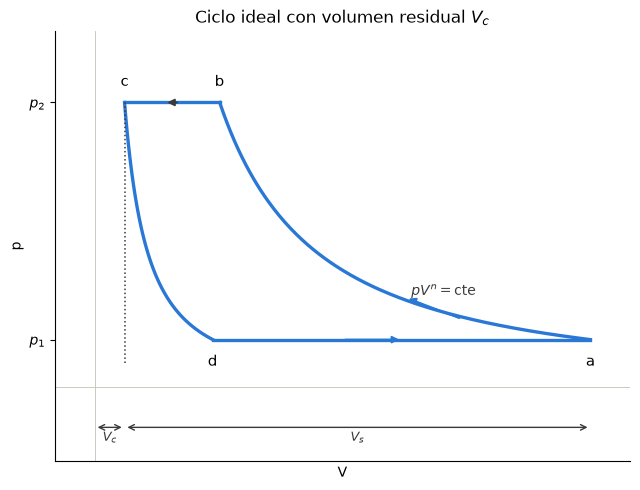

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
pv_diagram_ideal(ax, p1=1.0, p2=6.0, V1=10.0, n=1.3, Vc=0.6)   # Vc = 6 % de Vs, como en la prosa
ax.set_title("Ciclo ideal con volumen residual $V_c$")
plt.tight_layout(); plt.show()

Cuando se completa la carrera de entrega $bc$, el volumen residual $V_e$ está lleno de gas a una presión $p_2$ y una temperatura $T_2$.

A medida que el pistón avanza en la siguiente carrera de inducción, el aire se expande detrás de él hasta que se alcance la presión $p_1$.

Idealmente, tan pronto como la presión alcance $p_1$, comenzará la inducción de gas fresco y continuará hasta el final de esta carrera en $a$.

El gas se comprime entonces de acuerdo con la ley $pV^n = \text{cte}$, y la entrega comienza en $b$, controlada por las válvulas.

El efecto del volumen residual es reducir el volumen inducido en $p_1$ y $T_1$ de $V_s$ a ($V_a -V_b$). Las masas de gas en los cuatro puntos principales son tales que $\dot{m}_c = \dot{m}_d$ y $\dot{m}_b = \dot{m}_c$.

La masa entregada por unidad de tiempo se da por $(\dot{m}_b = \dot{m}_c)$, que es igual a la inducida, dada por ($\dot{m}_a = \dot{m}_d$). Las propiedades del fluido de trabajo cambian en los procesos a-b y c-d.

Podemos deducir la ecuación del trabajo de la misma manera que lo hicimos para el compresor simple con lo que la potencia con un volumen residual será:

$$ \dot{W} \ = \frac{n}{n-1}\dot{m}_a(T_2-T_1)-\frac{n}{n-1}\dot{m}_d(T_2-T_1)
= \frac{n}{n-1} R \dot{m}(T_2-T_1)$$

Donde $\dot{m}$ es la masa inducida por unidad de tiempo

Una comparación entre las ecuaciones, muestra que son idénticas. El trabajo realizado en la compresión de la masa de gas $\dot{m}_c$ o $\dot{m}_d$ en la compresión, de $a$ a $b$, se devuelve cuando el gas se expande de $c$ a $d$. Por lo tanto, el trabajo realizado por unidad de masa de aire entregada no se ve afectado por el tamaño del volumen residual.

Podemos además reescribir la expresión de la forma:

$$\dot{W} \ = \frac{n}{n-1}p_1 \dot{V} \left[ \left( \frac{p_2}{p_1}\right)^{(n-1)/n}-1 \right]$$


Además, si hay $f$ ciclos por unidad de tiempo, entonces tenemos

$$\dot{W} \ = \frac{n}{n-1}p_1 f(V_a-V_d) \left[ \left( \frac{p_2}{p_1}\right)^{(n-1)/n}-1 \right]$$

__Nota:__
La masa entregada por unidad de tiempo puede aumentarse diseñando la máquina para que sea de doble efecto, es decir, el gas se maneja en ambos lados del pistón, la carrera de inducción para un lado es la carrera de compresión para el otro.

##3. Eficiencia Volumétrica $\eta_v$

Se ha demostrado que uno de los efectos del volumen residual es reducir el volumen inducido a un valor menor que el volumen barrido. Esto significa que, para una inducción requerida, el tamaño del cilindro debe aumentarse en comparación con el calculado asumiendo un espacio muerto nulo. La eficiencia volumétrica se define de la siguiente manera:

$\eta_v$ = la masa de gas entregada, dividida por la masa de gas que llenaría el volumen barrido en las condiciones de presión y temperatura del aire libre

o

$\eta_v$ = el volumen de gas entregado medido a la presión y temperatura del aire libre, dividido por el volumen barrido del cilindro (12.15)

El volumen de aire tratado por unidad de tiempo por un compresor de aire se cita como la entrega de aire libre (FAD, por sus siglas en inglés), y es la tasa de flujo de volumen entregado, medido a la presión y temperatura de la atmósfera en la que se encuentra la máquina.

Las dos expresiones para $\eta_v$ pueden demostrarse como idénticas, es decir, si el FAD por ciclo es $V$, a una presión $p$ y temperatura $T$, entonces la masa entregada por ciclo es:

$m = \frac{pV}{RT}$

La masa necesaria para llenar el volumen barrido, $V_s$, a una presión $p$ y temperatura $T$ se da por:

$m_s = \frac{p V_s}{RT}$

por lo tanto:

$$\eta_v = \frac{m}{m_s}= \frac{pV}{RT} \times \frac{RT}{pV_s}= \frac{V}{V_s}  $$

La eficiencia volumétrica se puede obtener a partir del diagrama $p$-$V$ ya trazado en la §2 (con volumen residual): $\eta_v$ es simplemente la fracción del volumen barrido que llega a inducirse, $(V_a-V_d)/V_s$.

Sabemos que:

$$\frac{V_d}{V_c}=\left(\frac{p_2}{p_1}\right)^{1/n} ⇒ V_d = V_c \left(\frac{p_2}{p_1} \right)^{1/n}$$

Definimos el volumen inducido como
$$V_{ind}=V_a-V_d=V_s-V_c-V_d$$

$$V_{ind}=V_s+V_c-V_c\left(\frac{p_2}{p_1}\right)^{1/n}$$
$$=V_s - V_c \left[\left(\frac{p_2}{p_1}\right)^{1/n}-1\right]$$

Así podremos reescribir la eficiencia volumétrica como:

$$\eta_v = \frac{V_a-V_d}{V_s}=\frac{V_s-V_c \left[\left(\frac{p_2}{p_1}\right)^{1/n}-1\right]}{V_s}$$

$$\eta_v = 1- \frac{V_c}{V_s} \left[\left(\frac{p_2}{p_1}\right)^{1/n}-1\right]$$


Es importante destacar que esta definición de eficiencia volumétrica solo es consistente si las condiciones de presión y temperatura en el cilindro durante la carrera de inducción son idénticas a las del aire libre. De hecho, el gas se calentará debido a las paredes del cilindro y habrá una reducción en la presión debido a la caída de presión necesaria para inducir el gas en el cilindro contra la resistencia al flujo. Estas modificaciones al caso ideal requieren una aplicación más cuidadosa de las fórmulas previamente derivadas.

In [ ]:
# WIDGET 2 — eficiencia volumétrica vs relación de presión, con el diagrama p-V y V_ind sombreado
def widget2_etav(PR=6.0, Vc_frac=0.06, n=1.30):
    PRs = np.linspace(1.5, 12, 200)
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.9))
    for Vf, alfa, lw in [(0.02, 0.5, 1.6), (0.06, 0.5, 1.6), (0.30, 0.5, 1.6), (Vc_frac, 1.0, 2.8)]:
        eta = 1 - Vf*(PRs**(1/n) - 1)
        etiqueta = f"$V_c/V_s$={Vf:.2f}" + ("  ← actual" if alfa == 1.0 else "")
        ax0.plot(PRs, np.clip(eta, 0, 1)*100, lw=lw, alpha=alfa,
                color=COL["aire"] if alfa == 1 else COL["metal"], label=etiqueta)
    eta_pt = 1 - Vc_frac*(PR**(1/n) - 1)
    ax0.plot(PR, max(eta_pt, 0)*100, "o", ms=9, color=COL["perdida"], mec="white", mew=1.3)
    ax0.set_xlabel("relación de presión $p_2/p_1$"); ax0.set_ylabel("$\\eta_v$ [%]")
    ax0.set_title(f"$\\eta_v$ = {eta_pt*100:.1f} % en PR={PR:.1f}")
    ax0.legend(fontsize=9); ax0.grid(alpha=0.25); ax0.spines[["top", "right"]].set_visible(False)
    ax0.set_ylim(0, 105)
    pv_diagram_ideal(ax1, p1=1.0, p2=PR, V1=10.0, n=n, Vc=Vc_frac*10/(1), sombrear_ind=True)
    ax1.set_title("$V_{ind}$ sombreado = volumen realmente inducido")
    plt.tight_layout(); plt.show()

interact(widget2_etav,
         PR=FloatSlider(6.0, min=1.5, max=12.0, step=0.25, description="PR=p₂/p₁"),
         Vc_frac=FloatSlider(0.06, min=0.02, max=0.35, step=0.01, description="Vc/Vs"),
         n=FloatSlider(1.30, min=1.0, max=1.40, step=0.02, description="n"));

interactive(children=(FloatSlider(value=6.0, description='PR=p₂/p₁', max=12.0, min=1.5, step=0.25), FloatSlide…

##4. Ciclo real de compresión

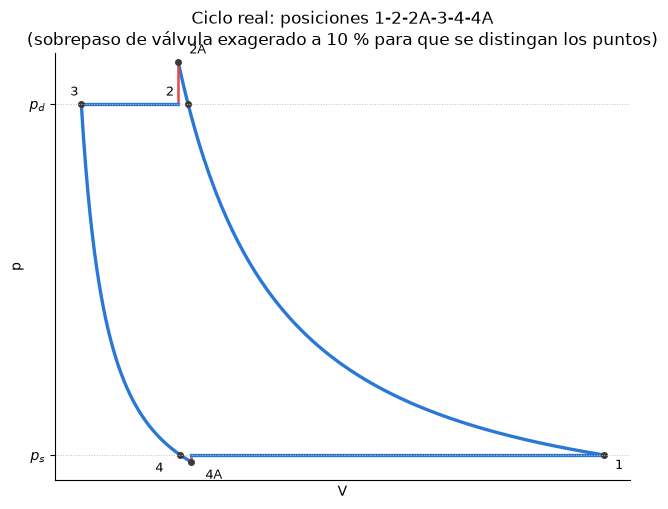

In [ ]:
# Diagrama del ciclo real (Phillippi/Turbomachinery Labs) — función reutilizable en §4
def pv_diagram_real(ax, p1=1.0, p2=6.0, V1=10.0, Vc=0.6, n=1.3,
                    dP_s=0.0, dP_d=0.0, sombrear=False):
    V2 = V1*(p1/p2)**(1/n)
    Pd_open = p2*(1+dP_d)
    V_2A = V1*(p1/Pd_open)**(1/n)
    Vd = Vc*(p2/p1)**(1/n)
    Ps_open = p1*(1-dP_s)
    V_4A = Vc*(p2/Ps_open)**(1/n)
    Vcomp = np.linspace(V_2A, V1, 150); Pcomp = p1*(V1/Vcomp)**n
    Vexp = np.linspace(Vc, V_4A, 150); Pexp = p2*(Vc/Vexp)**n
    ax.plot(Vcomp, Pcomp, color=COL["aire"], lw=2.4)                        # 1->2->2A
    ax.plot([V_2A, V_2A], [Pd_open, p2], color=COL["perdida"], lw=1.8)      # asentamiento de válvula
    ax.plot([V_2A, Vc], [p2, p2], color=COL["aire"], lw=2.4)                # 2A(asentado)->3
    ax.plot(Vexp, Pexp, color=COL["aire"], lw=2.4)                          # 3->4->4A
    ax.plot([V_4A, V_4A], [Ps_open, p1], color=COL["perdida"], lw=1.8)
    ax.plot([V_4A, V1], [p1, p1], color=COL["aire"], lw=2.4)                # 4A(asentado)->1
    pts = [(V1, p1, "1", (8, -10)), (V2, p2, "2", (-16, 6)), (V_2A, Pd_open, "2A", (8, 6)),
           (Vc, p2, "3", (-8, 6)), (Vd, p1, "4", (-18, -12)), (V_4A, Ps_open, "4A", (10, -12))]
    for Vx, Px, lbl, off in pts:
        ax.plot(Vx, Px, "o", ms=4, color=COL["tinta"])
        ax.annotate(lbl, (Vx, Px), textcoords="offset points", xytext=off, fontsize=9.5)
    if sombrear:
        ax.fill(np.append(Vcomp[Pcomp >= p2], [V_2A, V2]),
               np.append(Pcomp[Pcomp >= p2], [Pd_open, p2]), color=COL["perdida"], alpha=0.4)
        ax.fill(np.append(Vexp[Pexp <= p1], [V_4A, Vd]),
               np.append(Pexp[Pexp <= p1], [Ps_open, p1]), color=COL["perdida"], alpha=0.4)
    ax.axhline(p2, color=COL["metal"], lw=0.7, ls=":"); ax.axhline(p1, color=COL["metal"], lw=0.7, ls=":")
    ax.set_xlabel("V"); ax.set_ylabel("p")
    ax.set_yticks([p1, p2]); ax.set_yticklabels(["$p_s$", "$p_d$"]); ax.set_xticks([])
    ax.set_ylim(p1*0.65, p2*1.12)
    ax.spines[["top", "right"]].set_visible(False)
    return dict(V1=V1, V2=V2, V_2A=V_2A, Vc=Vc, Vd=Vd, V_4A=V_4A)

fig, ax = plt.subplots(figsize=(6.5, 5.2))
pv_diagram_real(ax, dP_s=0.10, dP_d=0.10, sombrear=False)
ax.set_title("Ciclo real: posiciones 1-2-2A-3-4-4A\n(sobrepaso de válvula exagerado a 10 % para que se distingan los puntos)")
plt.tight_layout(); plt.show()

Podemos representar un ciclo real típico de un compresor mediante el diagrama $p$-$V$ anterior donde:

En la posición 1 tiene el volumen máximo $V_1$ de gas atrapado en la cámara de compresión y ese gas está a presión y temperatura de succión. En esta posición también, todas las válvulas del compresor están cerradas y el pistón está en reposo. Todas las válvulas del compresor son válvulas de retención simples con resorte y no son accionadas por ningún medio externo. A medida que el cigüeñal gira, el pistón se moverá y el volumen dentro de la cámara de compresión disminuirá (pasando de la Posición 1 a la 2).

Desde la Posición 1, a medida que el volumen disminuye, la presión del gas aumenta. Cuando la presión dentro de la cámara de compresión se vuelve ligeramente mayor que la presión de descarga $2A$, la válvula de descarga del compresor se abrirá.

En la Posición 2, la válvula de descarga se abre y, mientras el pistón sigue moviéndose, el gas a presión y temperatura de descarga es expulsado de la cámara de compresión a través de la válvula de descarga del compresor y hacia el conducto de gas de descarga del cilindro.

En la Posición 3, el pistón se detiene, la válvula de descarga del compresor se cierra.

En la Posición 4, la presión dentro de la cámara de compresión será ligeramente menor que la presión de succión (PS), lo que hará que la válvula de succión del compresor se abra. Con la válvula de succión abierta, la cámara de compresión queda abierta al conducto de gas de succión y, a medida que el pistón continúa moviéndose, el volumen sigue aumentando y la cámara de compresión se llena de gas a presión y temperatura de succión. El pistón vuelve a la Posición 1, se detiene y el proceso se repite.

> **La física detrás de "ligeramente mayor" / "ligeramente menor":** las válvulas de un compresor reciprocante son de retención simple, cargadas por resorte — se abren *solas* cuando la diferencia de presión vence al resorte y a la inercia del disco. No hay manera de abrirlas exactamente en $p_2$ o $p_1$: el gas debe **sobrepasar** ($2\to2A$) o **caer por debajo** ($4\to4A$) de la presión nominal antes de que la válvula ceda. Ese sobrepaso/caída es exactamente la "interacción aire-válvula", y cuesta trabajo: es área extra en el diagrama $p$-$V$ que no estaría si las válvulas se abrieran instantáneamente en $p_1,p_2$. El widget de la página siguiente lo hace visible y medible.

###4.1 Eficiencia Volumétrica

A partir del diagrama $p$-$V$ podemos definir $\eta_v$ introduciendo nuevos términos ahora como:

$$\eta_v = 1-\frac{V_c}{V_s}\left[\frac{Z_s}{Z_d}\left(\frac{p_d}{p_s} \right)^{1/n}-1 \right]$$

Donde:
- $Z_S$ = Factor de compresibilidad @ $P_S$ y $T_S$
- $Z_D$ = Factor de compresibilidad @ $P_D$ y $T_D$
- $P_D$ = Presión de descarga, absoluta
- $P_S$ = Presión de succión, absoluta
- $n$ = exponente **politrópico** (coincide con el exponente adiabático $k$ solo en el caso límite isentrópico, $n=k$ — ver la tabla de la §1.0)

In [ ]:
# WIDGET 3 (flagship) — interacción aire-válvulas: sobrepaso/caída de presión y pérdida de potencia
def widget3_valvulas(dP_s=0.03, dP_d=0.03, n=1.30, PR=6.0, i=150):
    r = simular_ciclo(n=n, PR=PR, Vc_frac=0.06, rpm=600, dP_s_frac=dP_s, dP_d_frac=dP_d, frames=480)
    r0 = simular_ciclo(n=n, PR=PR, Vc_frac=0.06, rpm=600, dP_s_frac=0.0, dP_d_frac=0.0, frames=480)
    W_real, W_ideal = trabajo_ciclo(r["V"], r["P"]), trabajo_ciclo(r0["V"], r0["P"])
    perdida_pct = (W_real - W_ideal)/W_ideal*100

    fig = plt.figure(figsize=(11.5, 5.4))
    ax0 = fig.add_axes([0.06, 0.12, 0.55, 0.8])
    ax1 = fig.add_axes([0.70, 0.55, 0.27, 0.35]); ax1.axis("off")   # indicador succión
    ax2 = fig.add_axes([0.70, 0.12, 0.27, 0.35]); ax2.axis("off")   # indicador descarga

    d = pv_diagram_real(ax0, p1=r["p1"]/1e5, p2=r["p2"]/1e5, V1=r["V1"]*1e3, Vc=r["Vc"]*1e3,
                        n=n, dP_s=dP_s, dP_d=dP_d, sombrear=True)
    Vi, Pi = r["V"][i]*1e3, r["P"][i]/1e5
    ax0.plot(Vi, Pi, "o", ms=11, color=COL["aire"], mec="white", mew=1.6, zorder=6)
    ax0.set_title(f"pérdida de potencia en válvulas: {perdida_pct:.2f} %\n"
                 f"Ẇ_real={W_real*(r['rpm']/60)/1000:.2f} kW vs Ẇ_ideal={W_ideal*(r['rpm']/60)/1000:.2f} kW",
                 fontsize=10.5)

    v_estado = r["valve"][i]
    for ax, activo, nombre, col_on in [(ax1, v_estado == 1, "SUCCIÓN", COL["abierta"]),
                                       (ax2, v_estado == 2, "DESCARGA", COL["abierta"])]:
        color = col_on if activo else COL["cerrada"]
        ax.add_patch(Circle((0.5, 0.5), 0.32, fc=color, ec=COL["tinta"], lw=1.5, transform=ax.transAxes))
        ax.text(0.5, 0.5, "ABIERTA" if activo else "cerrada", ha="center", va="center",
                fontsize=10, color="white" if activo else COL["tinta"], fontweight="bold",
                transform=ax.transAxes)
        ax.text(0.5, 0.94, f"válvula de {nombre.lower()}", ha="center", fontsize=10,
                color=COL["tinta"], transform=ax.transAxes)
    plt.show()

play3 = Play(value=150, min=0, max=479, step=3, interval=45)
i_sl3 = IntSlider(150, min=0, max=479, description="θ (frame)")
jslink((play3, "value"), (i_sl3, "value"))
dPs_sl = FloatSlider(0.03, min=0.0, max=0.20, step=0.01, description="ΔP succión")
dPd_sl = FloatSlider(0.03, min=0.0, max=0.20, step=0.01, description="ΔP descarga")
n_sl3 = FloatSlider(1.30, min=1.0, max=1.40, step=0.02, description="n")
PR_sl3 = FloatSlider(6.0, min=2.0, max=10.0, step=0.5, description="PR")
out3 = interactive_output(widget3_valvulas, {"dP_s": dPs_sl, "dP_d": dPd_sl, "n": n_sl3,
                                             "PR": PR_sl3, "i": i_sl3})
display(VBox([HBox([play3, i_sl3]), HBox([dPs_sl, dPd_sl, n_sl3, PR_sl3]), out3]))

**Explora con el widget:** con $\Delta P_{succión}=\Delta P_{descarga}=0$ se recupera el ciclo ideal (2≡2A, 4≡4A, sin sombreado). Al subir los sobrepasos, aparecen las dos cuñas rojas y la pérdida de potencia crece — resortes de válvula más rígidos (necesarios para que la válvula no rebote a alta velocidad) sacrifican eficiencia. Es el mismo compromiso que aparece en cualquier válvula de retención: **rapidez de respuesta vs. pérdida de carga**.

##5. Multietapas de compresión
La eficiencia volumétrica puede mejorarse llevando a cabo la compresión en dos etapas. Después de la primera etapa de compresión, el fluido se pasa a un cilindro más pequeño en el que el gas se comprime a la presión final requerida. Si la máquina tiene dos etapas, el gas se entregará al final de esta etapa, pero podría entregarse a un tercer cilindro para relaciones de presión más altas. Los cilindros de las etapas sucesivas se dimensionan para tomar el volumen de gas entregado desde la etapa anterior.

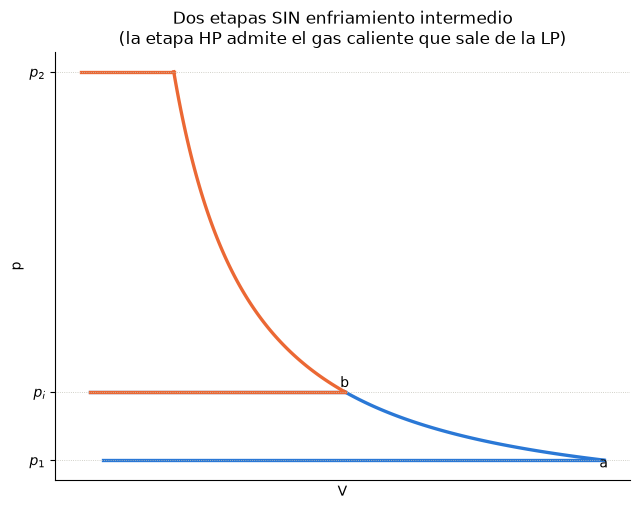

In [ ]:
# Diagrama de fase multietapa — función reutilizable en §5
def pv_diagram_multistage(ax, p1=1.0, p2=9.0, pi=None, n=1.3, T1=300.0, intercooled=False):
    pi = pi if pi is not None else p1*(p2/p1)**0.4     # ilustrativo (no necesariamente óptimo)
    mR = 1.0
    V1 = mR*T1/p1
    Tb = T1*(pi/p1)**((n-1)/n)
    Vb = mR*Tb/pi
    VLP = np.linspace(Vb, V1, 100); PLP = p1*(V1/VLP)**n
    ax.plot(VLP, PLP, color=COL["aire"], lw=2.4)
    ax.plot([Vb, Vb*0.05], [pi, pi], color=COL["aire"], lw=2.4)         # entrega LP
    ax.plot([V1*0.05, V1], [p1, p1], color=COL["aire"], lw=2.4)         # induccion LP
    ax.text(V1, p1*0.85, "a", ha="center", fontsize=10)
    ax.text(Vb, pi*1.04, "b", ha="center", fontsize=10)

    casos = [(Tb, "caliente (sin enfriar)", COL["etapa2"], "-" if not intercooled else "--", 1.0 if not intercooled else 0.55)]
    if intercooled:
        casos.append((T1, "enfriada (intercooler)", COL["aire"], "-", 1.0))
    for Ta2, nom, col, ls, alfa in casos:
        Va2 = mR*Ta2/pi
        Tb2 = Ta2*(p2/pi)**((n-1)/n)
        Vb2 = mR*Tb2/p2
        VHP = np.linspace(Vb2, Va2, 100); PHP = pi*(Va2/VHP)**n
        ax.plot(VHP, PHP, color=col, lw=2.4, ls=ls, alpha=alfa)
        ax.plot([Vb2, Vb2*0.05], [p2, p2], color=col, lw=2.4, ls=ls, alpha=alfa)
        ax.plot([Va2*0.05, Va2], [pi, pi], color=col, lw=2.4, ls=ls, alpha=alfa)
    Va2_c, Va2_h = mR*T1/pi, mR*Tb/pi
    if intercooled:
        Tb2c, Tb2h = T1*(p2/pi)**((n-1)/n), Tb*(p2/pi)**((n-1)/n)
        Vb2c, Vb2h = mR*Tb2c/p2, mR*Tb2h/p2
        Vs = np.linspace(min(Vb2c, Vb2h), max(Va2_c, Va2_h), 120)
        Pcal = np.clip(pi*(Va2_h/Vs)**n, None, p2); Pfrio = np.clip(pi*(Va2_c/Vs)**n, None, p2)
        ax.fill_between(Vs, np.minimum(Pcal, p2), np.minimum(Pfrio, p2),
                        where=(Pcal >= Pfrio), color=COL["abierta"], alpha=0.3)
        ax.text((Va2_c+Va2_h)/2, pi*1.35, "ahorro por\nenfriamiento", ha="center",
                fontsize=8.5, color=COL["abierta"])
    ax.axhline(p1, color=COL["metal"], lw=0.6, ls=":"); ax.axhline(pi, color=COL["metal"], lw=0.6, ls=":")
    ax.axhline(p2, color=COL["metal"], lw=0.6, ls=":")
    ax.set_yticks([p1, pi, p2]); ax.set_yticklabels(["$p_1$", "$p_i$", "$p_2$"])
    ax.set_xticks([]); ax.set_xlabel("V"); ax.set_ylabel("p")
    ax.spines[["top", "right"]].set_visible(False)

fig, ax = plt.subplots(figsize=(6.5, 5.2))
pv_diagram_multistage(ax, p1=1.0, p2=9.0, n=1.3, intercooled=False)
ax.set_title("Dos etapas SIN enfriamiento intermedio\n(la etapa HP admite el gas caliente que sale de la LP)")
plt.tight_layout(); plt.show()

La compresión isoterma ideal solo se puede lograr si el enfriamiento ideal es continuo. Esto es difícil de lograr durante la compresión normal. Con la compresión multietapa, surge la oportunidad de enfriar el gas mientras se transfiere de un cilindro al siguiente, al hacerlo pasar por un intercooler. Si el interenfriamiento es completo, el gas ingresará a la segunda etapa a la misma temperatura a la que ingresó a la primera etapa. El ahorro de trabajo obtenido mediante el interenfriamiento se muestra en el área sombreada en la Figura. Los dos diagramas de fase $abcd$ y $a'b'c'd'$ se muestran con una presión común, $p_i$. Esto no ocurre en una máquina real ya que hay una pequeña caída de presión entre los cilindros.

__Diagrama de fase para un compresor de dos etapas__

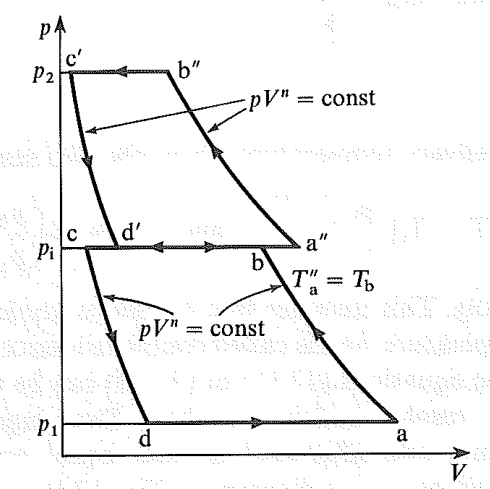

(Eastop & McConkey, 2006)

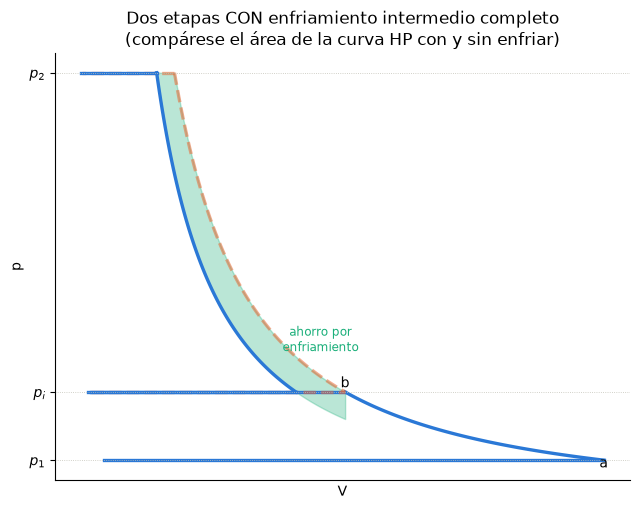

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5.2))
pv_diagram_multistage(ax, p1=1.0, p2=9.0, n=1.3, intercooled=True)
ax.set_title("Dos etapas CON enfriamiento intermedio completo\n(compárese el área de la curva HP con y sin enfriar)")
plt.tight_layout(); plt.show()

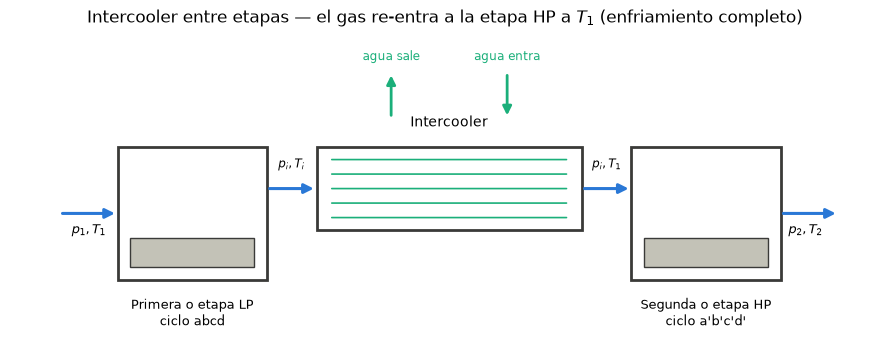

In [ ]:
# Esquema del equipo — dos cilindros + intercooler (reemplaza el diagrama de planta del original)
fig, ax = plt.subplots(figsize=(9, 4.2))
for cx, ancho, nombre in [(1.0, 1.8, "Primera o etapa LP\nciclo abcd"), (7.2, 1.8, "Segunda o etapa HP\nciclo a'b'c'd'")]:
    ax.add_patch(Rectangle((cx, 0.4), ancho, 1.6, fc="none", ec=COL["tinta"], lw=2))
    ax.add_patch(Rectangle((cx+0.15, 0.55), ancho-0.3, 0.35, fc=COL["metal"], ec=COL["tinta"]))
    ax.text(cx+ancho/2, -0.15, nombre, ha="center", fontsize=9)
ax.add_patch(Rectangle((3.4, 1.0), 3.2, 1.0, fc="none", ec=COL["tinta"], lw=2))
for yy in np.linspace(1.15, 1.85, 5):
    ax.add_patch(FancyArrowPatch((3.55, yy), (6.45, yy), arrowstyle="-", color=COL["agua"], lw=1.2))
ax.text(5.0, 2.25, "Intercooler", ha="center", fontsize=10)
ax.add_patch(FancyArrowPatch((4.3, 2.35), (4.3, 2.9), arrowstyle="-|>", mutation_scale=13, color=COL["agua"], lw=2))
ax.add_patch(FancyArrowPatch((5.7, 2.9), (5.7, 2.35), arrowstyle="-|>", mutation_scale=13, color=COL["agua"], lw=2))
ax.text(4.3, 3.05, "agua sale", ha="center", fontsize=8.5, color=COL["agua"])
ax.text(5.7, 3.05, "agua entra", ha="center", fontsize=8.5, color=COL["agua"])
ax.add_patch(FancyArrowPatch((2.8, 1.5), (3.4, 1.5), arrowstyle="-|>", mutation_scale=14, color=COL["aire"], lw=2.2))
ax.add_patch(FancyArrowPatch((6.6, 1.5), (7.2, 1.5), arrowstyle="-|>", mutation_scale=14, color=COL["aire"], lw=2.2))
ax.add_patch(FancyArrowPatch((0.3, 1.2), (1.0, 1.2), arrowstyle="-|>", mutation_scale=14, color=COL["aire"], lw=2.2))
ax.text(0.65, 0.95, "$p_1,T_1$", ha="center", fontsize=9)
ax.text(3.1, 1.75, "$p_i,T_i$", ha="center", fontsize=8.5)
ax.text(6.9, 1.75, "$p_i,T_1$", ha="center", fontsize=8.5)
ax.add_patch(FancyArrowPatch((9.0, 1.2), (9.7, 1.2), arrowstyle="-|>", mutation_scale=14, color=COL["aire"], lw=2.2))
ax.text(9.3, 0.95, "$p_2,T_2$", ha="center", fontsize=9)
ax.set_xlim(-0.3, 10.2); ax.set_ylim(-0.4, 3.4); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Intercooler entre etapas — el gas re-entra a la etapa HP a $T_1$ (enfriamiento completo)")
plt.tight_layout(); plt.show()

La temperatura de entrega entre los dos estados está dada por:

$$T_i=T_1\left(\frac{p_i}{p_1}\right)^{(n-1)/n} \ \text{y}\ \ T_2 = T_1 \left(\frac{p_i}{p_1}\right)^{(n-1)/n}  $$

###5.1 Presión ideal intermedia

El valor elegido para la presión intermedia $p_i$ influye en el trabajo que se debe realizar sobre el gas y su distribución entre las etapas. La condición para que el trabajo realizado sea mínimo se demostrará para la compresión de dos etapas, pero puede extenderse a cualquier número de etapas.

Trabajo total = Trabajo de la etapa LP + Trabajo de la etapa HP.

Así pues la potencia de compresión total está dada por.

$$\dot{W}= \frac{n}{n-1}\dot{m}RT_1 \left[ \left( \frac{p_i}{p_1}\right)^{(n-1)/n}-1 \right] + \frac{n}{n-1}\dot{m}RT_1 \left[ \left( \frac{p_2}{p_i}\right)^{(n-1)/n}-1 \right] $$

$$\dot{W} = \frac{n}{n-1}\dot{m}RT_1 \left[ \left( \frac{p_i}{p_1}\right)^{(n-1)/n}-1 +\left( \frac{p_2}{p_i}\right)^{(n-1)/n}-1\right]$$


Si $p_1$, $T_1$ y $p_2$ son fijos el valor óptimo de $p_i$ hace que la potencia sea mínima cuando:

 $$\frac{d\dot{W}}{dp_i} = 0$$

 por lo que el valor de $p_i$ es mínimo cuando:

 $$\frac{d}{dp_i}\left[ \left( \frac{p_i}{p_1}\right)^{(n-1)/n}+\left( \frac{p_2}{p_i}\right)^{(n-1)/n}-2\right] = 0$$

  $$\frac{d}{dp_i}\left[ \left( \frac{1}{p_1}\right)^{(n-1)/n}p_i^{(n-1)/n}+p_2^{(n-1)/n}\left( \frac{1}{p_i}\right)^{(n-1)/n}-2\right] = 0$$
$$p_1^{-(n-1)/n}\left( \frac{n-1}{n}\right)p_i^{(n-1)/n-1} +p_2^{(n-1)/n}\left( \frac{n-1}{n}\right)p_i^{(n-1)/n-1}=0$$

$$p_1^{-(n-1)/n}\left( \frac{n-1}{n}\right)p_i^{-1/n}=p_2^{(n-1)/n}\left( \frac{n-1}{n}\right)p_i^{(1-2n)/n}$$

por lo tanto:
$$p_i^{2(n-1)/n} = (p_1p_2)^{(n-1)/n}  $$

y

$$p_i =\sqrt{p_1p_2}$$

*(nota de edición: la versión anterior de esta lección omitía la raíz en este paso — el álgebra de las líneas siguientes, que ya usaba $\sqrt{p_1p_2}$, confirma que este es el resultado correcto.)*

o

$$\frac{p_i}{p_1} =\frac{p_2}{p_i}$$

Lo que quiere decir que la relación de presión en ambas etapas es la misma

$$\dot{W}_{min} = 2 \dot{W}$$

$$=2 \frac{n\dot{m}RT_1}{n-1} \left[\left(\frac{p_i}{p_1}\right)^{(n-1)/2n}-1\right]$$

O escribiendo en términos de la relación de presión $p_2/p_1$

$$\frac{p_i}{p_1}=\frac{\sqrt{p_1p_2}}{p_1}= \sqrt{\frac{p_2}{p_1}}$$

Con lo que:

$$\dot{W}_{min}= 2 \frac{n\dot{m}RT_1}{n-1} \left[\left(\frac{p_2}{p_1}\right)^{(n-1)/2n}-1\right]$$

se puede demostrar extendiendo para $z$ etapas de compresión.

$$\dot{W}_{min}= z \frac{n}{n-1} \dot{m}RT_1\left[\left(\frac{p_2}{p_1}\right)^{(n-1)/zn}-1\right]$$

la relación de presión para cada etapa será.

$$\left(\frac{p_2}{p_1}\right)^{1/z}$$

In [ ]:
# WIDGET 4 — presión intermedia óptima: curva Ẇ(p_i) + generalización a z etapas
def Wdot_2stage(pi, p1, p2, n, mdotR_T1):
    return n/(n-1)*mdotR_T1*((pi/p1)**((n-1)/n) - 1 + (p2/pi)**((n-1)/n) - 1)

def Wdot_zstage(z, p1, p2, n, mdotR_T1):
    return z*n/(n-1)*mdotR_T1*((p2/p1)**((n-1)/(z*n)) - 1)

def widget4_pi_optima(p1_bar=1.0, p2_bar=9.0, n=1.30, z_actual=2):
    p1, p2 = p1_bar*1e5, p2_bar*1e5
    mdotR_T1 = 1.0*287.0*300.0   # base: 1 kg/s de aire a 300 K
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.9))

    pis = np.linspace(p1*1.02, p2*0.98, 300)
    Ws = Wdot_2stage(pis, p1, p2, n, mdotR_T1)/1000
    ax0.plot(pis/1e5, Ws, color=COL["aire"], lw=2.4)
    pi_analitico = np.sqrt(p1*p2)
    res = minimize_scalar(lambda pi: Wdot_2stage(pi, p1, p2, n, mdotR_T1), bounds=(p1*1.001, p2*0.999),
                          method="bounded")
    pi_numerico = res.x
    ax0.axvline(pi_analitico/1e5, color=COL["perdida"], lw=1.3, ls="--")
    ax0.plot(pi_numerico/1e5, res.fun/1000, "o", ms=9, color=COL["perdida"], mec="white", mew=1.3)
    ax0.annotate(f"mínimo en $p_i=\\sqrt{{p_1p_2}}$={pi_analitico/1e5:.2f} bar\n"
                 f"(numérico: {pi_numerico/1e5:.3f} bar, err {abs(pi_numerico-pi_analitico)/pi_analitico*100:.3f} %)",
                 xy=(pi_analitico/1e5, res.fun/1000), xytext=(pi_analitico/1e5*1.15, Ws.max()*0.8),
                 fontsize=9.5, color=COL["tinta"], arrowprops=dict(arrowstyle="->", color=COL["tinta"], lw=1))
    ax0.set_xlabel("$p_i$ [bar]"); ax0.set_ylabel("Ẇ (2 etapas) [kW]")
    ax0.set_title(f"$p_1$={p1_bar:.1f} bar, $p_2$={p2_bar:.1f} bar, n={n:.2f}")
    ax0.grid(alpha=0.25); ax0.spines[["top", "right"]].set_visible(False)

    zs = np.arange(1, 6)
    Wz = np.array([Wdot_zstage(z, p1, p2, n, mdotR_T1) for z in zs])/1000
    colores = [COL["etapa2"] if z != z_actual else COL["aire"] for z in zs]
    ax1.bar(zs, Wz, color=colores, width=0.6)
    for z, W in zip(zs, Wz):
        ax1.text(z, W+Wz.max()*0.02, f"{W:.1f}", ha="center", fontsize=9)
    ax1.set_xlabel("número de etapas z"); ax1.set_ylabel("Ẇ_min [kW]")
    ahorro = (Wz[0]-Wz[z_actual-1])/Wz[0]*100
    ax1.set_title(f"z={z_actual}: ahorro de {ahorro:.1f} % vs. una sola etapa\n(rendimientos decrecientes)")
    ax1.set_xticks(zs); ax1.grid(axis="y", alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(widget4_pi_optima,
         p1_bar=FloatSlider(1.0, min=0.5, max=3.0, step=0.1, description="p₁ [bar]"),
         p2_bar=FloatSlider(9.0, min=3.0, max=20.0, step=0.5, description="p₂ [bar]"),
         n=FloatSlider(1.30, min=1.0, max=1.40, step=0.02, description="n"),
         z_actual=IntSlider(2, min=1, max=5, description="z etapas"));

interactive(children=(FloatSlider(value=1.0, description='p₁ [bar]', max=3.0, min=0.5), FloatSlider(value=9.0,…

##6. Eficiencia del compresor

###6.1 Eficiencia Isentrópica

La eficiencia isentrópica de un compresor se define como la relación entre el trabajo de entrada requerido para elevar la presión de un gas a un valor especificado de una manera isentrópica y el trabajo de entrada real:

$$\eta_c = \frac{\text{Trabajo isentrópico del compresor}}{\text{Trabajo real del compresor}}$$

*(En el lenguaje de la §1.0: el proceso isentrópico es exactamente el caso límite $n=k$ — la referencia de "máximo trabajo" de nuestra tabla inicial. $\eta_c$ mide qué tan lejos opera el compresor real de ese límite.)*

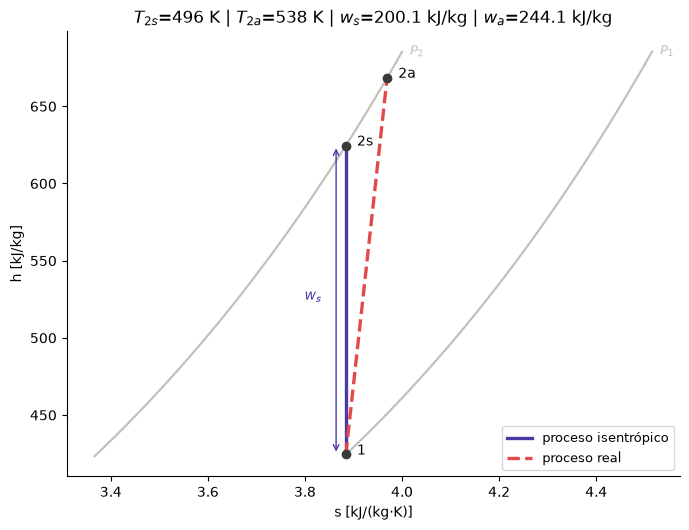

In [ ]:
# Diagrama h-s del compresor con propiedades REALES de aire (CoolProp) — función reutilizable
def hs_diagram_compresor(ax, P1_kPa=100.0, T1_C=25.0, P2_kPa=600.0, eta_c=0.82):
    P1, T1, P2 = P1_kPa*1e3, T1_C+273.15, P2_kPa*1e3
    h1 = PropsSI("H", "P", P1, "T", T1, "Air")
    s1 = PropsSI("S", "P", P1, "T", T1, "Air")
    h2s = PropsSI("H", "P", P2, "S", s1, "Air")
    T2s = PropsSI("T", "P", P2, "S", s1, "Air")
    w_s = h2s - h1
    w_a = w_s/eta_c
    h2a = h1 + w_a
    T2a = PropsSI("T", "P", P2, "H", h2a, "Air")
    s2a = PropsSI("S", "P", P2, "H", h2a, "Air")

    Ts = np.linspace(T1, max(T2a, T2s)*1.03, 80)
    s_P1 = np.array([PropsSI("S", "P", P1, "T", T, "Air") for T in Ts])
    h_P1 = np.array([PropsSI("H", "P", P1, "T", T, "Air") for T in Ts])
    s_P2 = np.array([PropsSI("S", "P", P2, "T", T, "Air") for T in Ts])
    h_P2 = np.array([PropsSI("H", "P", P2, "T", T, "Air") for T in Ts])
    ax.plot(s_P1/1e3, h_P1/1e3, color=COL["metal"], lw=1.6)
    ax.plot(s_P2/1e3, h_P2/1e3, color=COL["metal"], lw=1.6)
    ax.text(s_P1[-1]/1e3, h_P1[-1]/1e3, "  $P_1$", va="center", fontsize=9, color=COL["metal"])
    ax.text(s_P2[-1]/1e3, h_P2[-1]/1e3, "  $P_2$", va="center", fontsize=9, color=COL["metal"])

    ax.plot([s1/1e3, s1/1e3], [h1/1e3, h2s/1e3], color=COL["isentropico"], lw=2.4, label="proceso isentrópico")
    ax.plot([s1/1e3, s2a/1e3], [h1/1e3, h2a/1e3], color=COL["perdida"], lw=2.4, ls="--", label="proceso real")
    for s, h, lbl in [(s1, h1, "1"), (s1, h2s, "2s"), (s2a, h2a, "2a")]:
        ax.plot(s/1e3, h/1e3, "o", ms=6, color=COL["tinta"])
        ax.annotate(lbl, (s/1e3, h/1e3), textcoords="offset points", xytext=(8, 0), fontsize=10)
    ax.annotate("", xy=(s1/1e3-0.02, h2s/1e3), xytext=(s1/1e3-0.02, h1/1e3),
                arrowprops=dict(arrowstyle="<->", color=COL["isentropico"], lw=1))
    ax.text(s1/1e3-0.05, (h1+h2s)/2/1e3, "$w_s$", color=COL["isentropico"], fontsize=10, ha="right")
    ax.set_xlabel("s [kJ/(kg·K)]"); ax.set_ylabel("h [kJ/kg]")
    ax.legend(fontsize=9, loc="lower right"); ax.spines[["top", "right"]].set_visible(False)
    return dict(h1=h1, s1=s1, T2s=T2s, h2s=h2s, w_s=w_s, w_a=w_a, T2a=T2a, h2a=h2a)

fig, ax = plt.subplots(figsize=(7, 5.4))
d = hs_diagram_compresor(ax, P1_kPa=100.0, T1_C=25.0, P2_kPa=600.0, eta_c=0.82)
ax.set_title(f"$T_{{2s}}$={d['T2s']:.0f} K | $T_{{2a}}$={d['T2a']:.0f} K | "
             f"$w_s$={d['w_s']/1e3:.1f} kJ/kg | $w_a$={d['w_a']/1e3:.1f} kJ/kg")
plt.tight_layout(); plt.show()

Cuando son insignificantes los cambios de energía potencial y cinética del gas mientras éste es comprimido, el trabajo de entrada para un compresor adiabático es igual al cambio de entalpía, por lo que para este caso la ecuación de rendimiento adquiere la forma.

$$ \eta_c =\frac{W_{isen}}{W_{real}}=\frac{h_{2 \ isen}-h_1}{h_{2 \ real}-h_1}$$

Donde $h_{2 \ isen}$ y $h_{2 \ real}$ son los valores de la entalpía en el estado de salida para los procesos de compresión isentrópico y real, respectivamente, como se ilustra en la figura.

El valor de la eficiencia isentrópica depende en gran medida del diseño del compresor. Los compresores mejor diseñados tienen eficiencias isentrópicas de 80 a 90%

In [ ]:
# WIDGET 5 — eficiencia isentrópica y diagrama h-s (aire real, CoolProp)
def widget5_etac(P1_kPa=100.0, T1_C=25.0, P2_kPa=600.0, eta_c=0.82):
    fig, ax = plt.subplots(figsize=(7.5, 5.6))
    d = hs_diagram_compresor(ax, P1_kPa, T1_C, P2_kPa, eta_c)
    ax.set_title(f"$\\eta_c$={eta_c:.0%} | $T_{{2s}}$={d['T2s']:.0f} K ({d['T2s']-273.15:.0f} °C) | "
                 f"$T_{{2a}}$={d['T2a']:.0f} K ({d['T2a']-273.15:.0f} °C)\n"
                 f"$w_s$={d['w_s']/1e3:.1f} kJ/kg | $w_a$={d['w_a']/1e3:.1f} kJ/kg "
                 f"| sobrecosto energético = {(d['w_a']-d['w_s'])/1e3:.1f} kJ/kg", fontsize=10.5)
    plt.tight_layout(); plt.show()

interact(widget5_etac,
         P1_kPa=FloatSlider(100.0, min=80, max=150, step=5, description="P₁ [kPa]"),
         T1_C=FloatSlider(25.0, min=0, max=45, step=1, description="T₁ [°C]"),
         P2_kPa=FloatSlider(600.0, min=200, max=1500, step=25, description="P₂ [kPa]"),
         eta_c=FloatSlider(0.82, min=0.6, max=0.95, step=0.01, description="η_c"));

interactive(children=(FloatSlider(value=100.0, description='P₁ [kPa]', max=150.0, min=80.0, step=5.0), FloatSl…

##7. Otros Compresores (Rotacionales)

Recordar cómo es la descripción de las máquinas hidráulicas rotacionales: Compresores axiales, compresores centrífugos y turbinas.

> **Alcance de esta lección:** de aquí en adelante seguimos dentro de las máquinas de **desplazamiento positivo** — Roots y Lysholm atrapan y desplazan un volumen fijo de gas por vuelta, igual que el pistón de las secciones 1-6, solo que con movimiento rotativo en vez de alternativo. Los compresores axiales y centrífugos (dinámicos, no volumétricos) y los **motores** de combustión interna reciprocantes quedan fuera del alcance de esta lección — se estudian por separado más adelante en el curso.

###7.1. Tipo Roots

> **¿Qué obstáculo resuelve, y cuál no?** Roots resuelve el problema del **desplazamiento continuo** (sin válvulas que abrir/cerrar, sin pérdidas de sobrepaso como en §4) — pero **no comprime nada dentro de la máquina**. El gas se atrapa a la presión de entrada $p_1$, se transporta intacto hasta el puerto de descarga, y **recién ahí** el gas a mayor presión del ducto de descarga refluye instantáneamente hacia la cámara para igualar la presión. Es *compresión externa*: toda la subida de presión ocurre de golpe, fuera de control del rotor, y ese reflujo brusco es puro trabajo perdido (aumenta con la relación de presión — por eso Roots se limita a relaciones de presión bajas, PR≲2).

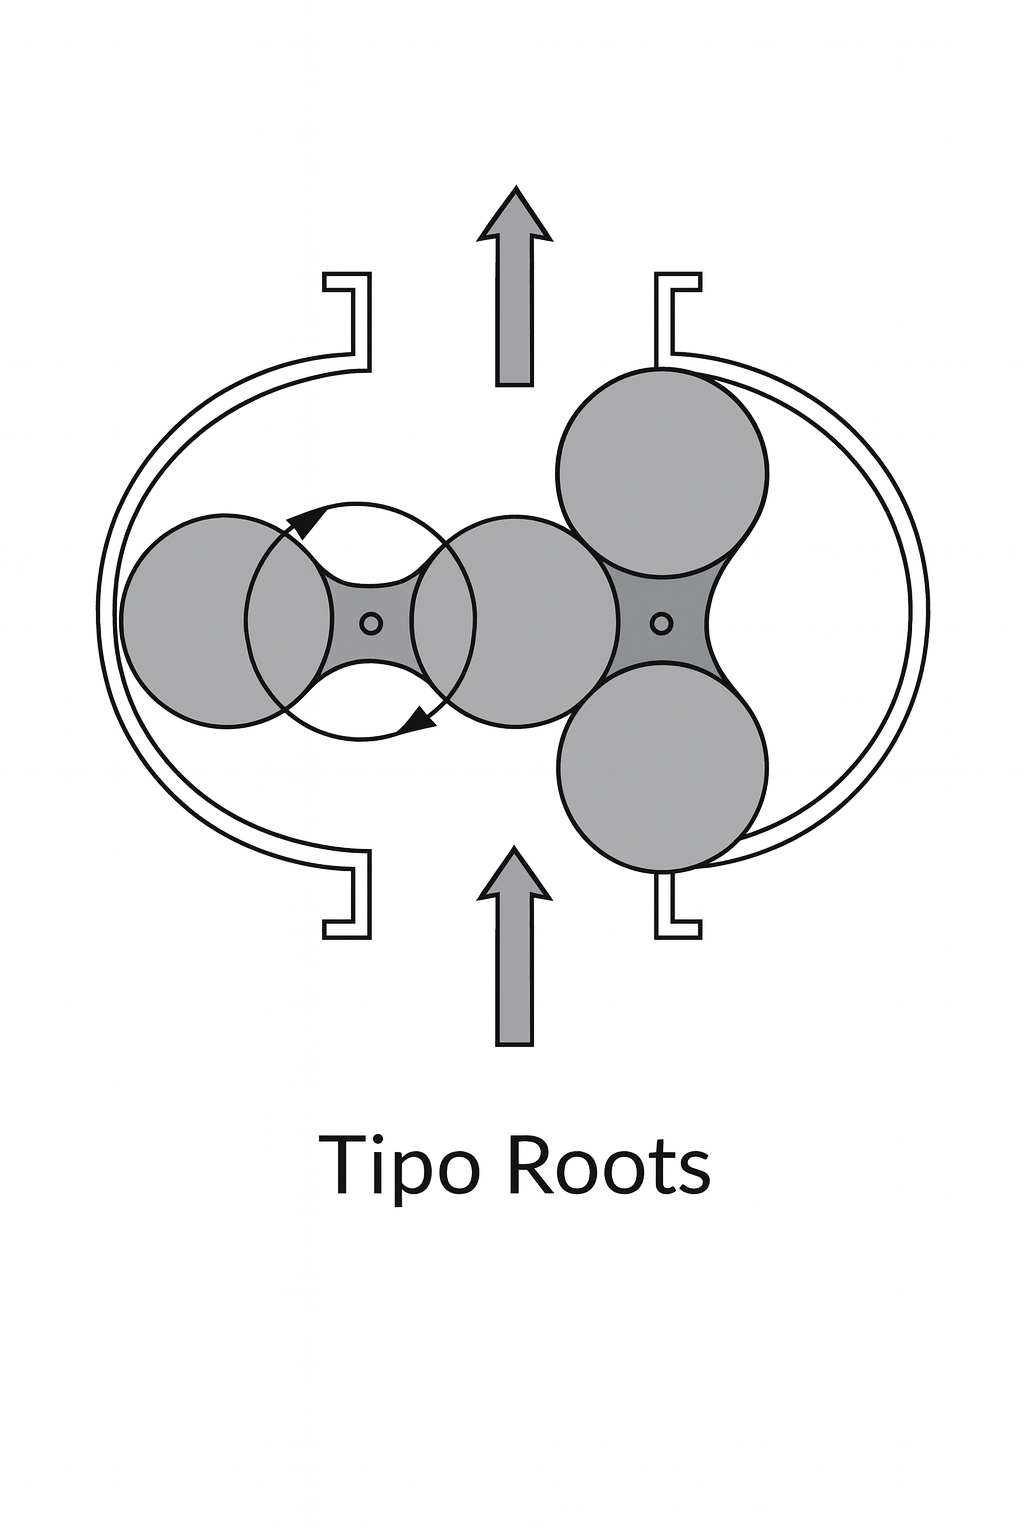

In [ ]:
# Esquema y animación — Roots (compresión externa) y Lysholm (compresión interna)
def dibujar_lobulos(ax, angulo_deg=0.0, n_lobulos=2):
    Rh, cx = 1.0, 1.05
    housing_y = 1.18*Rh
    ax.add_patch(FancyBboxPatch((-cx-Rh, -housing_y), 2*(cx+Rh), 2*housing_y,
                                boxstyle=f"round,pad=0,rounding_size={Rh:.3f}",
                                fc="#fdf6ee", ec=COL["tinta"], lw=2))
    ang = np.radians(angulo_deg)
    for sign in (-1, 1):
        cxr = sign*cx
        r_l = Rh*0.60
        offsets = np.linspace(0, 2*np.pi, n_lobulos, endpoint=False)
        fase = (np.pi/n_lobulos if sign > 0 else 0.0)     # rotores desfasados para "engranar"
        a0 = (ang if sign > 0 else -ang) + fase
        for off in offsets:
            a = a0 + off
            lx, ly = cxr + (Rh-r_l)*np.cos(a), (Rh-r_l)*np.sin(a)
            ax.add_patch(Circle((lx, ly), r_l, fc=COL["metal"], ec=COL["tinta"], lw=1.3, zorder=3))
        ax.add_patch(Circle((cxr, 0), Rh*0.10, fc=COL["tinta"], zorder=4))
    return Rh, cx, housing_y

def estado_pocket(angulo_deg, modo):
    # posicion angular de la "bolsa" de gas a lo largo del alojamiento (0=entrada, 340=justo antes de la salida)
    frac = min((angulo_deg % 360) / 340.0, 1.0)
    P_rel = 0.0 if (modo.startswith("Roots") and frac < 0.999) else (1.0 if modo.startswith("Roots") else frac**1.6)
    return frac, P_rel

def roots_lysholm(angulo_deg=90.0, modo="Roots (compresión externa)"):
    fig = plt.figure(figsize=(11, 4.8))
    ax0 = fig.add_axes([0.03, 0.08, 0.42, 0.86])
    ax1 = fig.add_axes([0.55, 0.14, 0.42, 0.74])
    Rh, cx, hy = dibujar_lobulos(ax0, angulo_deg, n_lobulos=2)
    frac, _ = estado_pocket(angulo_deg, modo)
    px = -cx + (2*cx)*frac
    py = hy*0.86
    ax0.add_patch(Circle((px, py), Rh*0.14, fc=COL["aire"], alpha=0.85, zorder=5, ec="white", lw=1))
    ax0.annotate("", xy=(-cx-Rh*0.3, hy*1.35), xytext=(-cx-Rh*0.9, hy*1.35),
                arrowprops=dict(arrowstyle="-|>", color=COL["aire"], lw=2))
    ax0.text(-cx-Rh*0.6, hy*1.55, "entrada", ha="center", fontsize=9, color=COL["aire"])
    ax0.annotate("", xy=(cx+Rh*0.9, hy*1.35), xytext=(cx+Rh*0.3, hy*1.35),
                arrowprops=dict(arrowstyle="-|>", color=COL["perdida"], lw=2))
    ax0.text(cx+Rh*0.6, hy*1.55, "salida", ha="center", fontsize=9, color=COL["perdida"])
    ax0.set_xlim(-cx-Rh*1.5, cx+Rh*1.5); ax0.set_ylim(-hy*1.7, hy*1.9)
    ax0.set_aspect("equal"); ax0.axis("off")
    ax0.set_title(modo.split(" (")[0] + " — vista frontal simplificada", fontsize=10.5)

    angs = np.linspace(0, 360, 300)
    fracs = np.minimum(angs/340.0, 1.0)
    if modo.startswith("Roots"):
        Prel = np.where(fracs < 0.999, 0.0, 1.0)
    else:
        Prel = fracs**1.6
    ax1.plot(angs, Prel, color=COL["aire"], lw=2.4)
    ax1.axvline(angulo_deg % 360, color=COL["tinta"], lw=1, ls=":")
    f_now, P_now = estado_pocket(angulo_deg, modo)
    ax1.plot(angulo_deg % 360, P_now, "o", ms=10, color=COL["perdida"], mec="white", mew=1.3)
    ax1.set_xlabel("posición del rotor [°]  (0=entrada, 340=puerto de salida)")
    ax1.set_ylabel("presión de la bolsa\n(0=$p_1$, 1=$p_2$)")
    ax1.set_title("compresión EXTERNA (salto)" if modo.startswith("Roots")
                 else "compresión INTERNA (gradual)", fontsize=10.5)
    ax1.set_ylim(-0.05, 1.15); ax1.grid(alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    plt.show()

play6 = Play(value=90, min=0, max=359, step=4, interval=50)
ang_sl6 = IntSlider(90, min=0, max=359, description="ángulo [°]")
jslink((play6, "value"), (ang_sl6, "value"))
modo_dd = Dropdown(options=["Roots (compresión externa)", "Lysholm (compresión interna)"],
                   description="tipo")
out6 = interactive_output(roots_lysholm, {"angulo_deg": ang_sl6, "modo": modo_dd})
display(VBox([HBox([play6, ang_sl6]), modo_dd, out6]))

###7.2. Tipo Lysholm

> **¿Qué obstáculo resuelve, que Roots no?** El tornillo (rotor macho y hembra, engranando helicoidalmente) reduce el volumen atrapado **de forma continua a lo largo de su eje**, exactamente como un pistón virtual que avanza mientras gira. Para cuando la bolsa de gas llega al puerto de descarga, ya está cerca de $p_2$ — el reflujo es pequeño. Es *compresión interna*, y por eso el Lysholm alcanza relaciones de presión y eficiencias mucho mayores que el Roots (ver el mapa de aplicación de la §7.3), a costa de una manufactura mucho más exigente (perfiles helicoidales de precisión).

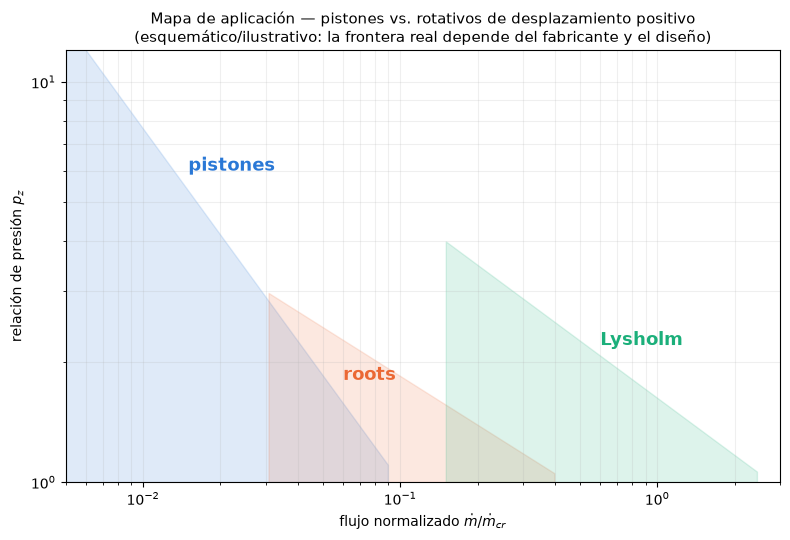

In [ ]:
# Mapa de aplicación (ilustrativo, adaptado) — pistones / Roots / Lysholm
fig, ax = plt.subplots(figsize=(8, 5.5))
flujo = np.logspace(-2.3, 0.5, 200)

def frontera(f, f0, f1, pz0, pz1):
    return pz0*(f/f0)**(np.log(pz1/pz0)/np.log(f1/f0))

ax.fill_between(flujo, 1, frontera(flujo, 0.006, 0.09, 12, 1.1),
                where=(flujo > 0.005) & (flujo < 0.09), color=COL["aire"], alpha=0.15)
ax.fill_between(flujo, 1, frontera(flujo, 0.03, 0.4, 3.0, 1.05),
                where=(flujo > 0.03) & (flujo < 0.4), color=COL["etapa2"], alpha=0.15)
ax.fill_between(flujo, 1, frontera(flujo, 0.15, 2.5, 4.0, 1.05),
                where=(flujo > 0.15) & (flujo < 2.5), color=COL["abierta"], alpha=0.15)
ax.text(0.015, 6, "pistones", fontsize=13, fontweight="bold", color=COL["aire"])
ax.text(0.06, 1.8, "roots", fontsize=13, fontweight="bold", color=COL["etapa2"])
ax.text(0.6, 2.2, "Lysholm", fontsize=13, fontweight="bold", color=COL["abierta"])
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(5e-3, 3); ax.set_ylim(1, 12)
ax.set_xlabel("flujo normalizado $\\dot{m}/\\dot{m}_{cr}$")
ax.set_ylabel("relación de presión $p_z$")
ax.set_title("Mapa de aplicación — pistones vs. rotativos de desplazamiento positivo\n"
             "(esquemático/ilustrativo: la frontera real depende del fabricante y el diseño)",
             fontsize=10.5)
ax.grid(alpha=0.2, which="both")
plt.tight_layout(); plt.show()

## Conclusión

Un compresor reciprocante es, de principio a fin, la Lección 1 hecha máquina: el trabajo de compresión es $\int P\,dV$ sobre un proceso $PV^n=\text{cte}$, y cada elemento de diseño responde a alejarse de las pérdidas que ese mismo proceso impone. El volumen residual y las válvulas explican por qué $\eta_v$ cae con la relación de presión; el sobrepaso necesario para abrir las válvulas de retención es la "interacción aire-válvula" que cuesta potencia extra; las multietapas con interenfriamiento son un intento explícito de empujar $n$ hacia $1$ (el límite isotérmico); y la eficiencia isentrópica mide qué tan lejos se queda el compresor real del límite opuesto, $n=k$. Los compresores rotativos de desplazamiento positivo —Roots y Lysholm— resuelven el mismo problema sin válvulas ni pistón, pero solo el Lysholm logra compresión *interna*: la diferencia entre "desplazar gas" y "comprimir gas" es, otra vez, una cuestión de qué tan cerca se sigue la curva $PV^n=\text{cte}$ dentro de la propia máquina.

---
### 8. Referencias
Eastop, T. D., & McConkey, A. (2006). Applied Thermodynamics for Engineering Technologists. Pearson/Prentice Hall.

Çengel, Y. A., Buesa, A. I., & Boles, M. A. (2015). Termodinámica. McGraw Hill.

Phillippi, G. (2016). Basic Thermodynamics Of Reciprocating Compression. Turbomachinery Laboratories, Texas A&M Engineering Experiment Station. Available electronically from https://hdl.handle.net/1969.1/159804.

Bell, I. H. et al. (2014). CoolProp. *Ind. Eng. Chem. Res.*, 53(6), 2498–2508.